In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

# Ajout du chemin vers les sources HELIOS
sys.path.insert(0, os.path.abspath('src'))

import helios
from helios.core.context import Layer

# Configuration de l'affichage
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'inferno'

## Étape 1 : La Scène Astrophysique

Nous définissons notre système cible :
- Une **Étoile** brillante au centre (type Soleil).
- Une **Planète** beaucoup moins lumineuse située à 1 UA (Unité Astronomique).

Pour cette démonstration, nous exagérons le flux de la planète pour qu'elle soit visible sans traitement extrême, mais le principe reste le même.

Scène configurée à 10.0 pc


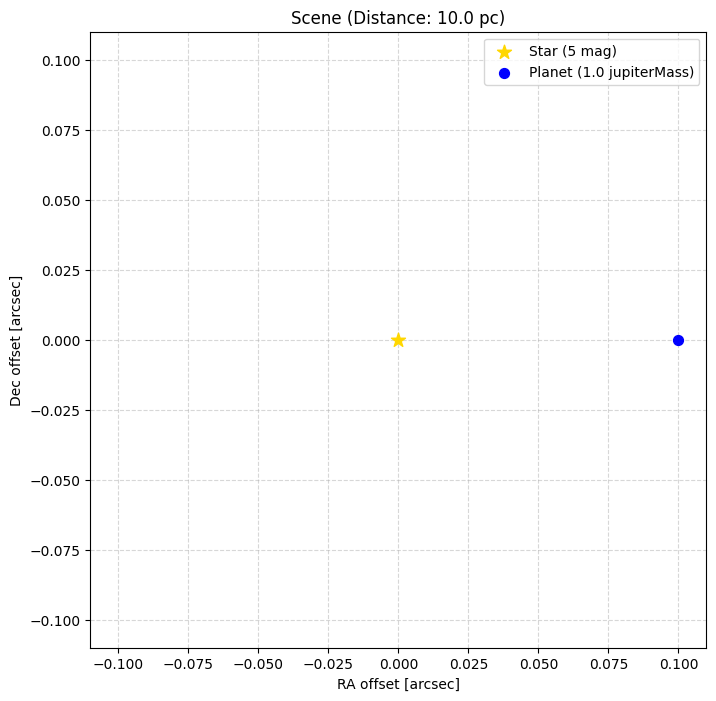

In [2]:
# Création de la scène
scene = helios.Scene(distance=10*u.pc, name="Système Cible")

# Ajout de l'étoile (au centre)
star = helios.Star(temperature=5778*u.K, magnitude=5, position=(0, 0))
scene.add(star)

# Ajout de la planète (à 0.1 seconde d'arc, soit 1 UA à 10 pc)
# Nous utilisons un albedo élevé et un rayon artificiel pour la visibilité de la démo
planet = helios.Planet(mass=1*u.M_jup, position=(0.1*u.arcsec, 0*u.arcsec), albedo=1.0)
# Hack pour la démo : on force la planète à être plus brillante
planet.magnitude = 10 
scene.add(planet)

print(f"Scène configurée à {scene.distance}")
scene.plot()
plt.show()

## Étape 2 : L'Interféromètre (Pupille)

Nous construisons un interféromètre simple composé de deux télescopes séparés par une ligne de base $B$.
- Diamètre des télescopes : 2 m
- Ligne de base ($B$) : 10 m

La configuration de la pupille définit comment la lumière est collectée.

Interféromètre : 2 télescopes, Base = 10.0 m


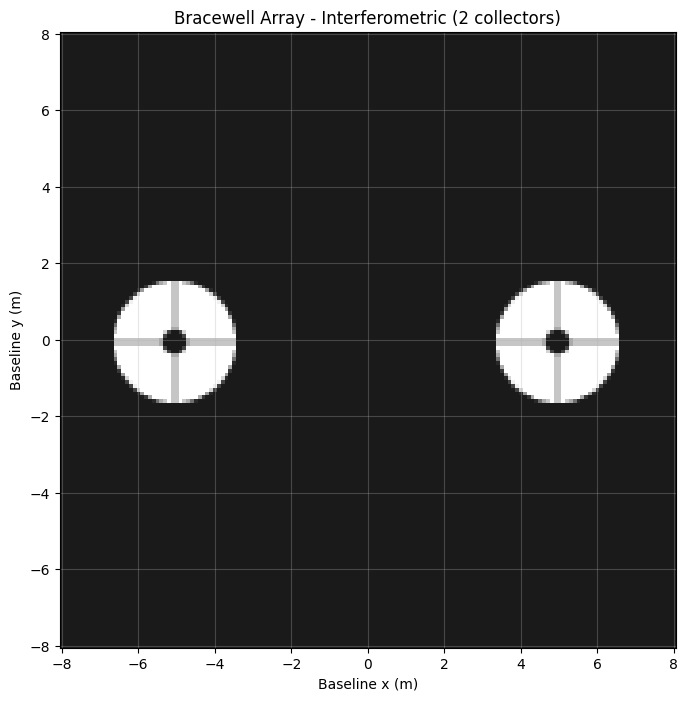

In [3]:
# Configuration de l'interféromètre
B = 10 * u.m  # Ligne de base
D = 2 * u.m   # Diamètre des télescopes

pupil = helios.Pupil(diameter=D)
pupil.add_disk(center=(0,0), radius=D/2)
pupil.add_spiders(arms=4, width=0.01*D)
pupil.add_central_obscuration(diameter=0.2*D)

interferometer = helios.TelescopeArray(name="Bracewell Array")
interferometer.add_collector(pupil, position=(-B/2, 0), size=D) # Télescope Gauche
interferometer.add_collector(pupil, position=(B/2, 0), size=D)  # Télescope Droit

print(f"Interféromètre : {len(interferometer.collectors)} télescopes, Base = {B}")

# Visualisation de la pupille
interferometer.plot_array()
plt.show()

## Étape 3 : Le Front d'Onde (Avant Nulling)

Observons le front d'onde (l'amplitude et la phase de la lumière) après avoir traversé les télescopes, mais avant toute combinaison.
- **Amplitude** : On voit les deux disques lumineux correspondant aux télescopes.
- **Phase** : Elle est uniforme (0 partout) car nous n'avons pas encore introduit de perturbations ou de déphasage.

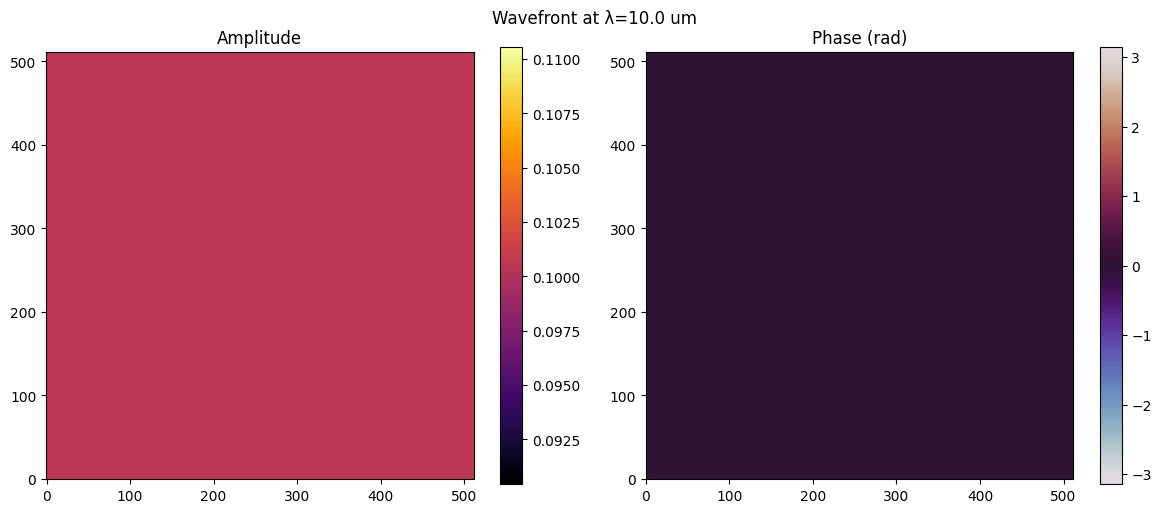

In [ ]:
# Génération du front d'onde initial depuis la scène
wavelength=10e-6*u.m
wf_initial = helios.Wavefront(wavelength=wavelength, size=512) # Infrarouge thermique (10 microns)
wf_scene = scene.process(wf_initial, None)
wf_scene.plot(title=f"Wavefront at λ={wavelength.to(u.um)}")
plt.show()

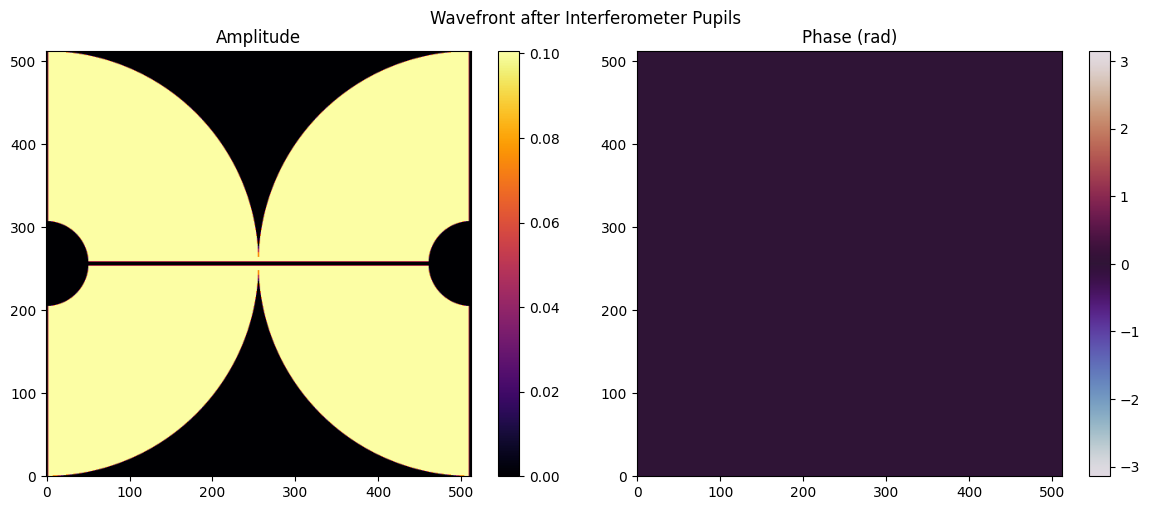

In [14]:
# Passage à travers les pupilles
wf_pupil = interferometer.process(wf_scene, None)
wf_pupil.plot(title="Wavefront after Interferometer Pupils")
plt.show()

## Étape 4 : Le "Nuller" (Déphasage de $\pi$)

C'est ici que la magie de Bracewell opère. Nous introduisons artificiellement un déphasage de $\pi$ (180°) sur l'un des deux télescopes.
- Cela inverse le signe du champ électrique sur une moitié de la pupille.
- L'étoile, étant sur l'axe, verra ses contributions s'annuler (interférences destructives).

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
C:\Users\vince\AppData\Local\Temp\ipykernel_8480\2573098581.py:25: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_title("Phase après Nulling (Saut de $\pi$)")


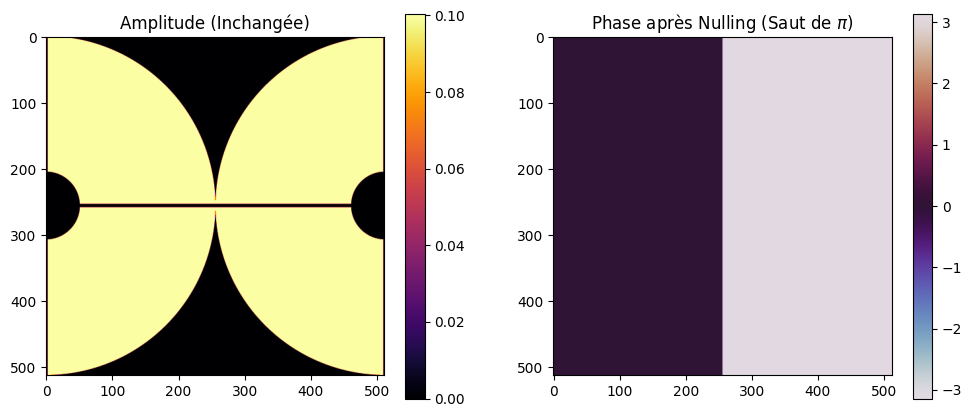

In [6]:
class BracewellPhaseShifter(Layer):
    """Composant personnalisé pour appliquer un déphasage de Pi sur la moitié droite."""
    def process(self, wavefront, context):
        # On copie pour ne pas modifier l'original
        wf = wavefront.copy()
        h, w = wf.field.shape
        # Application du déphasage sur la moitié droite de l'image (x > 0)
        # Note: exp(i * pi) = -1
        wf.field[:, w//2:] *= np.exp(1j * np.pi)
        return wf

nuller = BracewellPhaseShifter(name="Pi Shifter")
wf_nulled = nuller.process(wf_pupil, None)

# Visualisation après le Nuller
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Amplitude (Inchangée)
im1 = ax1.imshow(np.abs(wf_nulled.field), cmap='inferno')
ax1.set_title("Amplitude (Inchangée)")
plt.colorbar(im1, ax=ax1)

# Phase (Modifiée)
im2 = ax2.imshow(np.angle(wf_nulled.field), cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax2.set_title("Phase après Nulling (Saut de $\pi$)")
plt.colorbar(im2, ax=ax2)

plt.show()

## Étape 5 : Détection (Plan Focal)

Enfin, nous focalisons la lumière sur un détecteur (caméra). C'est l'équivalent de faire la transformée de Fourier du champ dans la pupille.

**Résultat attendu :**
- Au centre de l'image (où se trouve l'étoile), nous devrions voir une zone sombre ("null") due aux interférences destructives.
- La planète, située légèrement hors axe, ne subit pas exactement le même déphasage géométrique et devrait apparaître (ou du moins, ne pas être totalement éteinte).

*Note : Les franges d'interférence sont visibles. L'étoile est "éteinte" au centre des franges.*

C:\Users\vince\AppData\Local\Temp\ipykernel_8480\1558379071.py:8: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(image + 1e-10), cmap='inferno', extent=[-1, 1, -1, 1])


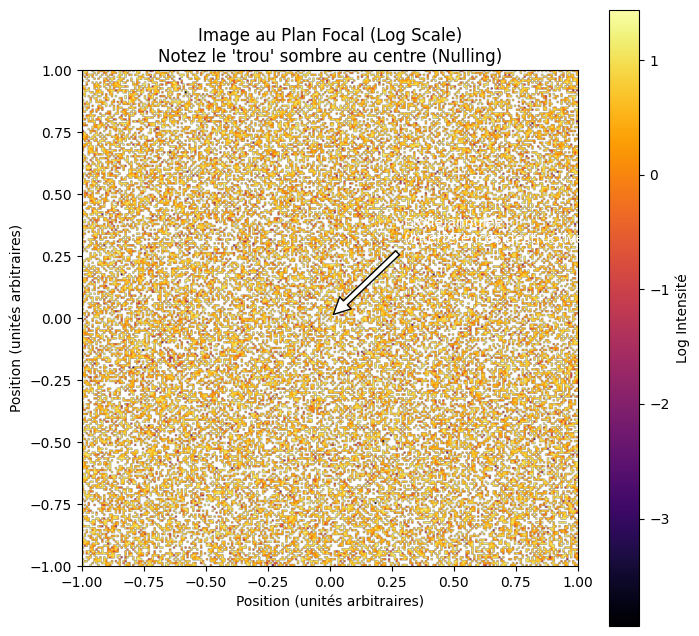

In [7]:
# Propagation vers le plan focal (Caméra)
camera = helios.Camera(pixels=(256, 256))
image = camera.process(wf_nulled, None)

# Visualisation
plt.figure(figsize=(8, 8))
# Échelle logarithmique pour mieux voir la dynamique
plt.imshow(np.log10(image + 1e-10), cmap='inferno', extent=[-1, 1, -1, 1])
plt.title("Image au Plan Focal (Log Scale)\nNotez le 'trou' sombre au centre (Nulling)")
plt.xlabel("Position (unités arbitraires)")
plt.ylabel("Position (unités arbitraires)")
plt.colorbar(label="Log Intensité")

# Annotation pour aider à comprendre
plt.annotate('Étoile annulée\n(Interférences destructives)', xy=(0, 0), xytext=(0.3, 0.3),
             arrowprops=dict(facecolor='white', shrink=0.05), color='white')

plt.show()